In [151]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from pathlib import Path

from pytagi import Normalizer as normalizer
from canari import DataProcess, Model, plot_data, plot_prediction, plot_states
from canari.component import LstmNetwork, WhiteNoise, LocalTrend

In [152]:
# project_root = Path.cwd().resolve().parents[0]
# data_file = str(project_root / "data/toy_time_series/sine.csv")
# df_raw = pd.read_csv(data_file, skiprows=1, delimiter=",", header=None)
# linear_space = np.linspace(0, 5, num=len(df_raw))
# # exponential_space=5*(np.exp(-linear_space)-1)
# acceleration_space=-2*linear_space**2-3*linear_space
# df_raw = df_raw.add(acceleration_space, axis=0)

# data_file_time = str(project_root / "data/toy_time_series/sine_datetime.csv")
# time_index = pd.read_csv(data_file_time, skiprows=1, delimiter=",", header=None)
# time_index = pd.to_datetime(time_index[0])
# df_raw.index = time_index
# df_raw.index.name = "time"
# df_raw.columns = ["values"]

df_raw = pd.read_csv(
    "/Users/michelwu/Desktop/Exp DAT/reel_data/1700B042.DAT",
    sep=";",  # Semicolon as delimiter
    quotechar='"',  # Double quotes as text qualifier
    engine="python",  # Python engine for complex cases
    na_values=[""],  # Treat empty strings as NaN
    skipinitialspace=True,  # Skip spaces after delimiter
    encoding="ISO-8859-1",
    parse_dates=["Date"],
    index_col="Date",
)
df = df_raw[["Deplacements cumulatif X (mm)"]]
# print(df.loc["1995"])
df = df.iloc[:]
mask = ~np.isnan(df)
df = df[mask].resample("M").mean()

In [153]:
data_processor = DataProcess(
    data=df,
    train_split=0.50,
    validation_split=0.1,
    output_col=[0],
)
train_data, validation_data, test_data, normalized_data = data_processor.get_splits()

In [154]:
df = pd.DataFrame({
    "ds": np.asarray(train_data["time"]).reshape(-1),
    "y":  np.asarray(train_data["y"]).reshape(-1),
})


11:05:59 - cmdstanpy - INFO - Chain [1] start processing
11:06:00 - cmdstanpy - INFO - Chain [1] done processing


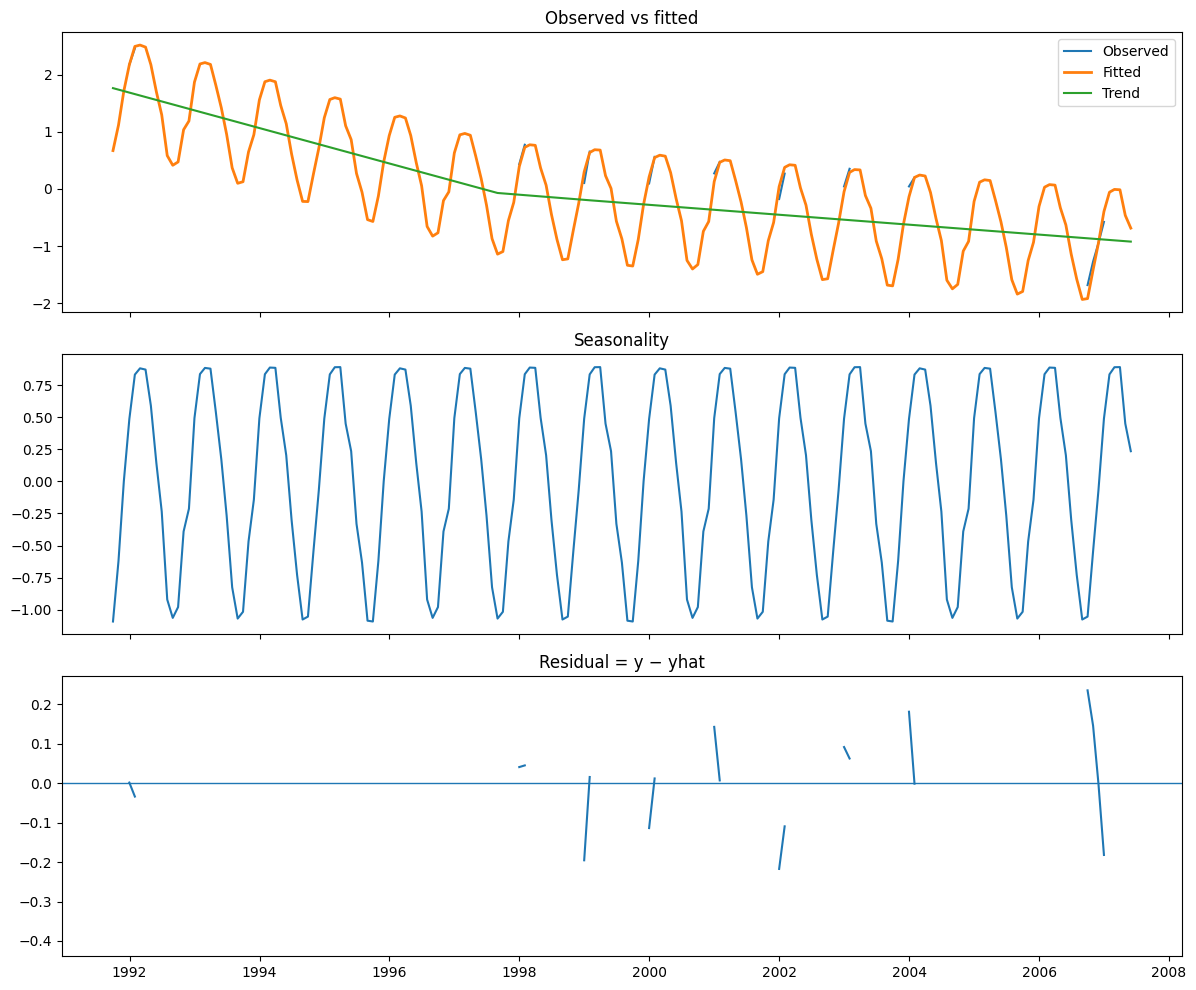

In [155]:
m = Prophet(
    yearly_seasonality=True,
    # weekly_seasonality=True,
    # daily_seasonality=True,
    # n_changepoints=0,
)
m.fit(df)

# Predict on observed dates only (no future forecast)
fcst = m.predict(df[["ds"]])

# --- Decomposition ---
trend = fcst["trend"]

# Sum Prophet seasonal/effect components that exist
season_cols = [c for c in ["yearly", "weekly", "daily", "holidays"] if c in fcst.columns]
seasonality = fcst[season_cols].sum(axis=1) if season_cols else 0.0
residual = df["y"].values - fcst["yhat"].values


# --- Plot ---
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(df["ds"], df["y"], label="Observed")
axes[0].plot(df["ds"], fcst["yhat"], label="Fitted", linewidth=2)
axes[0].plot(df["ds"], trend, label="Trend")
axes[0].legend()
axes[0].set_title("Observed vs fitted")

axes[1].plot(df["ds"], seasonality)
axes[1].set_title("Seasonality")

axes[2].plot(df["ds"], residual)
axes[2].axhline(0, linewidth=1)
axes[2].set_title("Residual = y − yhat")

plt.tight_layout()
plt.show()